In [15]:
import torch
import matplotlib.pyplot as plt
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)
from pathlib import Path
import torch
import numpy as np
from tqdm.auto import tqdm

from src.io import load_dataset
from src.dataset import OCTLayerDataset
from src.models.unet import UNet
from src.training.split import split_subjects

/Users/philipabakah/Desktop/projects/explore/oct-retinal-layer-segmentation


In [16]:
device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

mps


In [17]:
model = UNet(
    n_channels=1,
    n_classes=8,
)

model.load_state_dict(
    torch.load(
        "../checkpoints/best_model.pth",
        map_location=device,
    )
)

model.to(device)

model.eval()

UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): DownBlock(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [18]:
subjects = load_dataset("../datasets/duke/2015_BOE_Chiu")

_, val_subjects = split_subjects(subjects)

val_dataset = OCTLayerDataset(
    val_subjects,
    grader=1,
)

print(len(val_dataset))

22


In [19]:
def dice_score(prediction, target, num_classes=8):

    scores = []

    for c in range(num_classes):

        pred = prediction == c
        gt = target == c

        intersection = (pred & gt).sum()

        union = pred.sum() + gt.sum()

        if union == 0:
            scores.append(1.0)
            continue

        dice = (2.0 * intersection) / union

        scores.append(float(dice))

    return scores

In [20]:
def iou_score(prediction, target, num_classes=8):

    scores = []

    for c in range(num_classes):

        pred = prediction == c
        gt = target == c

        intersection = (pred & gt).sum()

        union = (pred | gt).sum()

        if union == 0:
            scores.append(1.0)
            continue

        scores.append(float(intersection / union))

    return scores

In [21]:
def pixel_accuracy(prediction, target):

    return float(
        (prediction == target).sum()
        / target.size
    )

In [22]:
all_dice = []
all_iou = []
all_accuracy = []

with torch.no_grad():

    for image, mask in tqdm(val_dataset):

        output = model(
            image.unsqueeze(0).to(device)
        )

        prediction = (
            output.argmax(dim=1)
            .squeeze(0)
            .cpu()
            .numpy()
        )

        mask = mask.numpy()

        all_dice.append(
            dice_score(prediction, mask)
        )

        all_iou.append(
            iou_score(prediction, mask)
        )

        all_accuracy.append(
            pixel_accuracy(
                prediction,
                mask,
            )
        )

  0%|          | 0/22 [00:00<?, ?it/s]

In [24]:
all_dice = np.array(all_dice)

all_iou = np.array(all_iou)

all_accuracy = np.array(all_accuracy)

In [10]:
print("=" * 40)
print("Dice + Cross-Entropy U-Net")
print("=" * 40)

print(f"Mean Dice : {all_dice.mean():.4f}")
print(f"Mean IoU  : {all_iou.mean():.4f}")
print(f"Pixel Acc : {all_accuracy.mean():.4f}")

print("=" * 40)

Dice + Cross-Entropy U-Net
Mean Dice : 0.8282
Mean IoU  : 0.7188
Pixel Acc : 0.9720


In [25]:
print("=" * 40)

print(
    f"Mean Dice : {all_dice.mean():.4f}"
)

print(
    f"Mean IoU  : {all_iou.mean():.4f}"
)

print(
    f"Pixel Acc : {all_accuracy.mean():.4f}"
)

print("=" * 40)

Mean Dice : 0.8328
Mean IoU  : 0.7233
Pixel Acc : 0.9711


In [26]:
layer_names = [
    "Layer 0",
    "Layer 1",
    "Layer 2",
    "Layer 3",
    "Layer 4",
    "Layer 5",
    "Layer 6",
    "Layer 7",
]

for i, name in enumerate(layer_names):

    print(
        f"{name:10s}: {all_dice[:, i].mean():.4f}"
    )

Layer 0   : 0.9899
Layer 1   : 0.8001
Layer 2   : 0.8870
Layer 3   : 0.7587
Layer 4   : 0.7282
Layer 5   : 0.8603
Layer 6   : 0.8299
Layer 7   : 0.8085


In [27]:
mean_dice_per_scan = all_dice.mean(axis=1)

worst = np.argsort(mean_dice_per_scan)[:10]

print(worst)

[11 18  4 21  0  3  2 16 20 14]


In [28]:
best = np.argsort(mean_dice_per_scan)[-10:]

print(best)

[17  6  9  1  8 19  7 10 13 12]


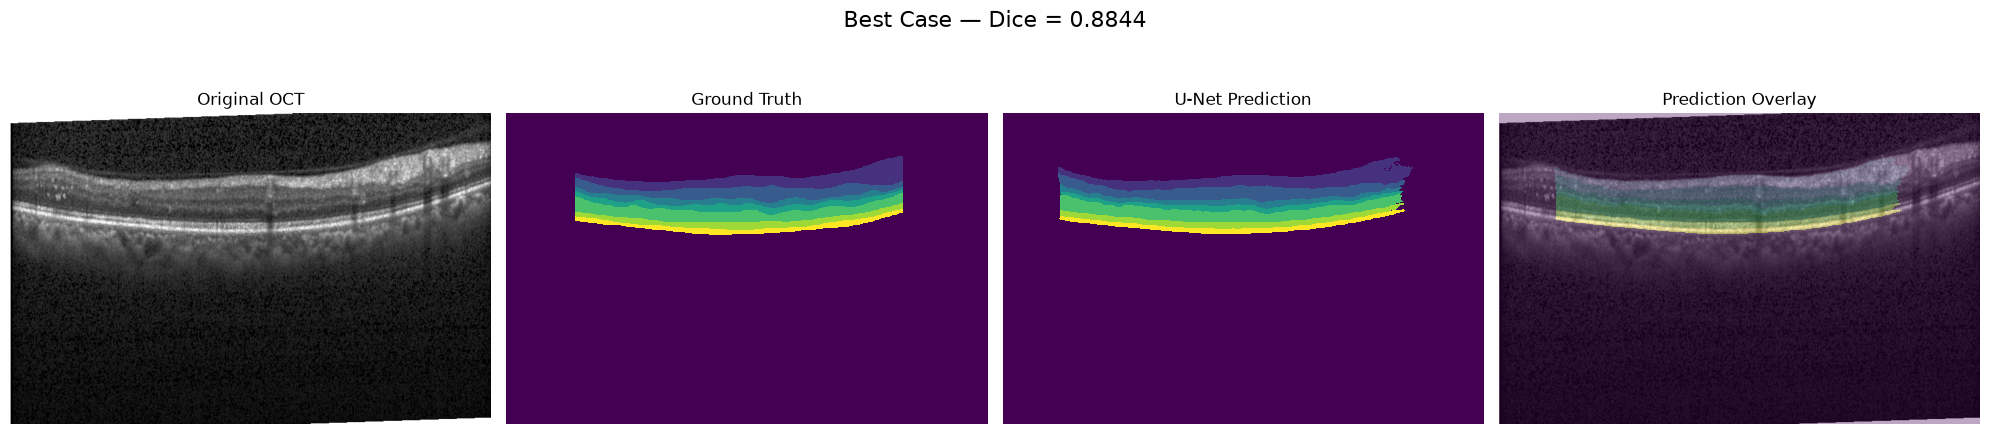

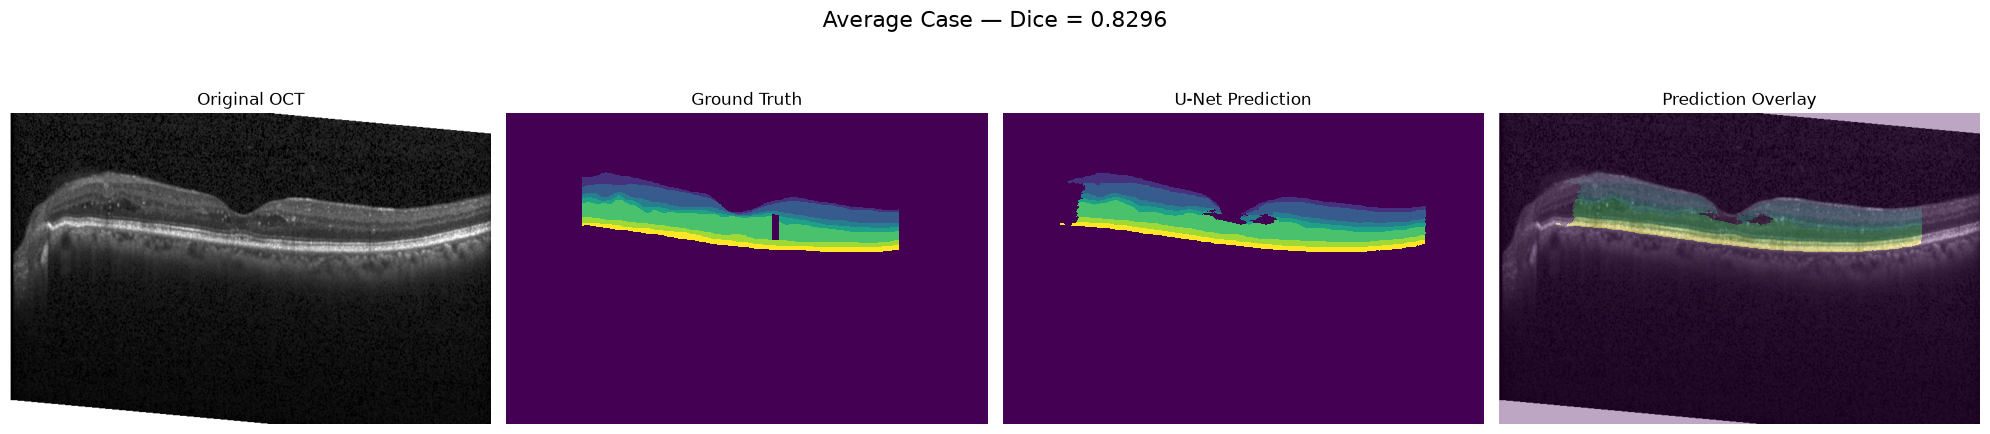

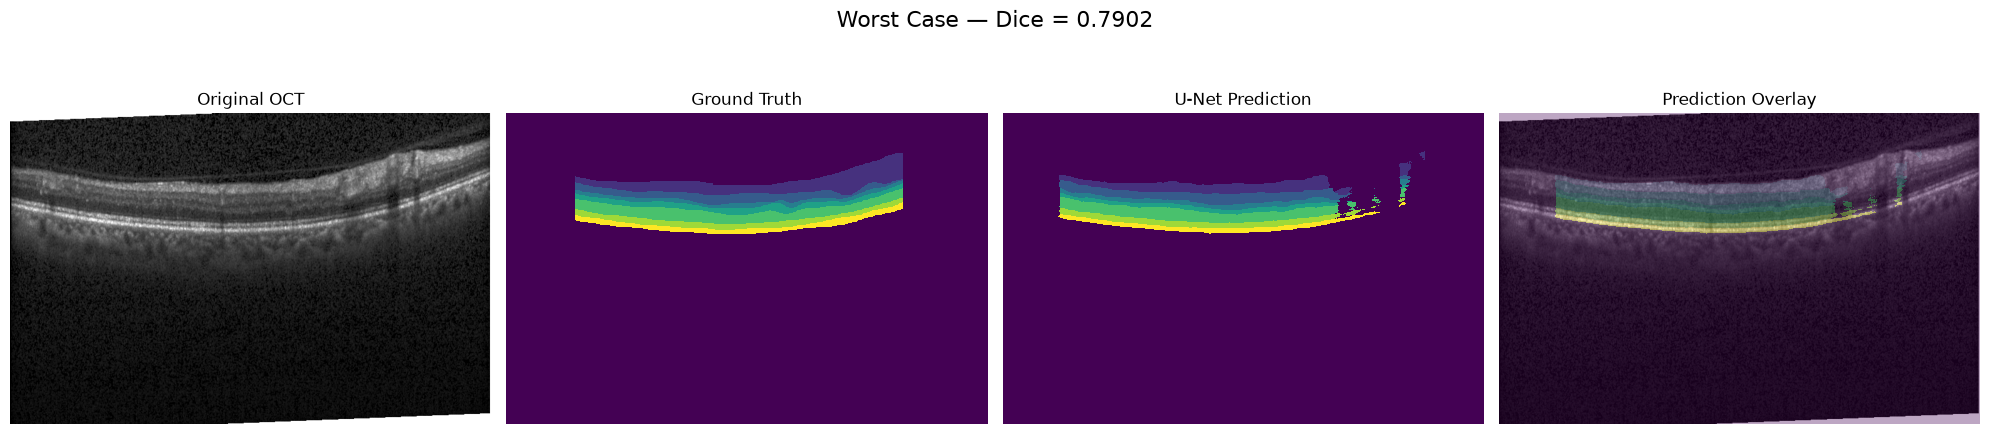

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import torch


# ---------------------------------------------------------
# Select representative scans
# ---------------------------------------------------------

# Compute mean Dice score per scan (across all layers)
mean_dice_scores = np.mean(all_dice, axis=1)

# Best-performing scan (within validation dataset range)
val_size = len(val_dataset)
val_indices = np.arange(val_size)
best_idx = val_indices[np.argmax(mean_dice_scores[:val_size])]

# Worst-performing scan (within validation dataset range)
worst_idx = val_indices[np.argmin(mean_dice_scores[:val_size])]

# Scan closest to the median Dice score (within validation dataset range)
median_dice = np.median(mean_dice_scores[:val_size])
average_idx = val_indices[np.argmin(np.abs(mean_dice_scores[:val_size] - median_dice))]

selected = {
    "Best": best_idx,
    "Average": average_idx,
    "Worst": worst_idx,
}


# ---------------------------------------------------------
# Get predictions
# ---------------------------------------------------------

model.eval()

results = {}

with torch.no_grad():

    for label, idx in selected.items():

        image, mask = val_dataset[idx]

        image_input = image.unsqueeze(0).to(device)

        logits = model(image_input)

        prediction = torch.argmax(
            logits,
            dim=1
        ).squeeze(0).cpu().numpy()

        image_np = image.squeeze(0).numpy()
        mask_np = mask.numpy()

        results[label] = {
            "image": image_np,
            "mask": mask_np,
            "prediction": prediction,
            "dice": mean_dice_scores[idx],
        }


# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

for label in ["Best", "Average", "Worst"]:

    result = results[label]

    image = result["image"]
    mask = result["mask"]
    prediction = result["prediction"]
    dice = result["dice"]

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(20, 5)
    )

    # Original OCT
    axes[0].imshow(
        image,
        cmap="gray"
    )
    axes[0].set_title("Original OCT")

    # Ground truth
    axes[1].imshow(
        mask,
        interpolation="nearest"
    )
    axes[1].set_title("Ground Truth")

    # Prediction
    axes[2].imshow(
        prediction,
        interpolation="nearest"
    )
    axes[2].set_title("U-Net Prediction")

    # Overlay
    axes[3].imshow(
        image,
        cmap="gray"
    )

    axes[3].imshow(
        prediction,
        alpha=0.35,
        interpolation="nearest"
    )

    axes[3].set_title("Prediction Overlay")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{label} Case — Dice = {dice:.4f}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

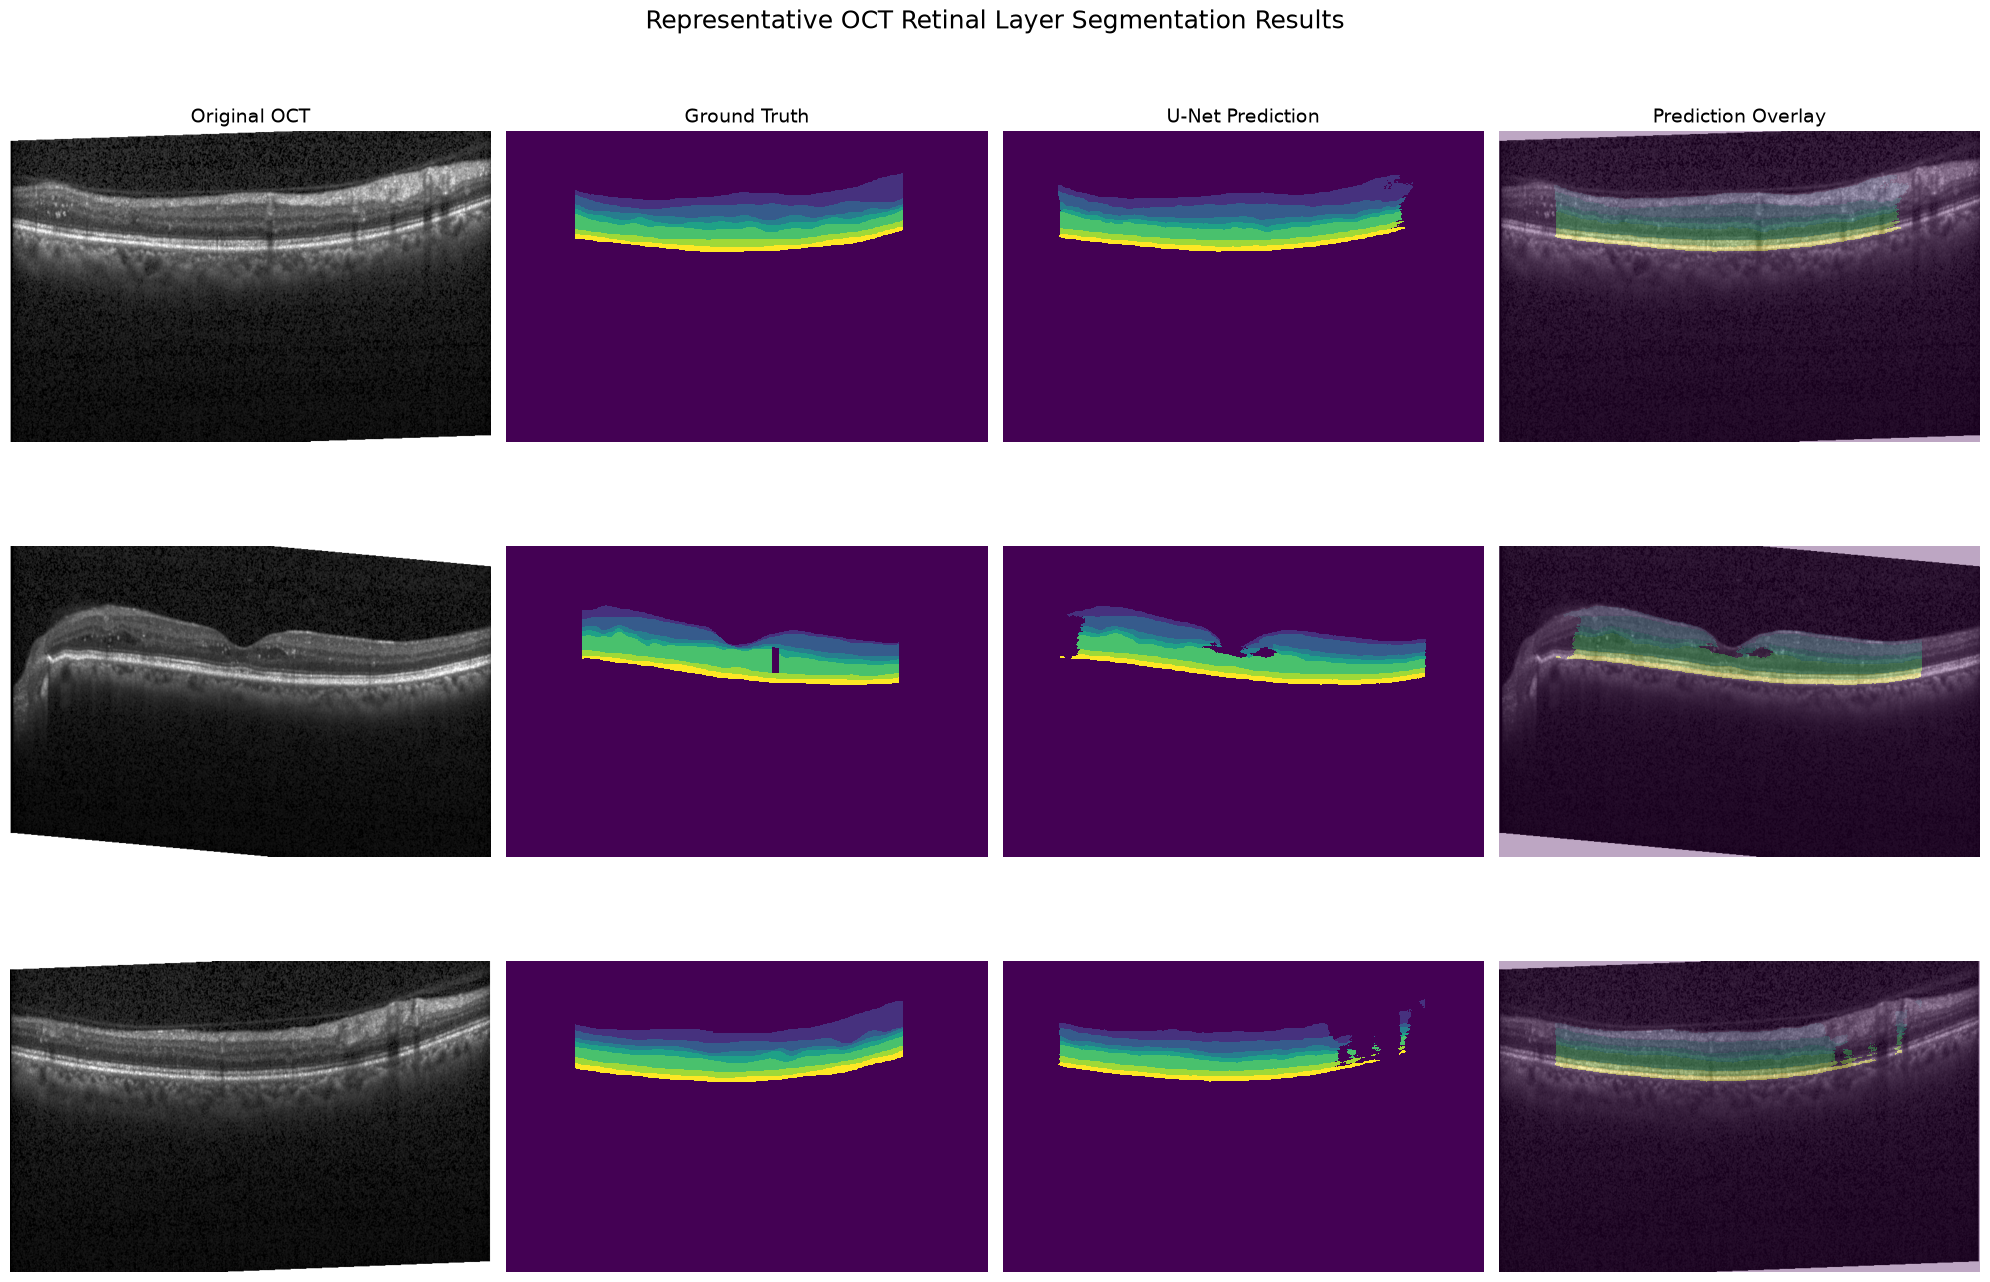

In [35]:
from pathlib import Path

Path("../figures").mkdir(
    parents=True,
    exist_ok=True
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(20, 14)
)

for row, label in enumerate(["Best", "Average", "Worst"]):

    result = results[label]

    image = result["image"]
    mask = result["mask"]
    prediction = result["prediction"]
    dice = result["dice"]

    axes[row, 0].imshow(
        image,
        cmap="gray"
    )

    axes[row, 1].imshow(
        mask,
        interpolation="nearest"
    )

    axes[row, 2].imshow(
        prediction,
        interpolation="nearest"
    )

    axes[row, 3].imshow(
        image,
        cmap="gray"
    )

    axes[row, 3].imshow(
        prediction,
        alpha=0.35,
        interpolation="nearest"
    )

    axes[row, 0].set_ylabel(
        f"{label}\nDice = {dice:.3f}",
        fontsize=12
    )

titles = [
    "Original OCT",
    "Ground Truth",
    "U-Net Prediction",
    "Prediction Overlay",
]

for col, title in enumerate(titles):
    axes[0, col].set_title(
        title,
        fontsize=14
    )

for ax in axes.flat:
    ax.axis("off")

plt.suptitle(
    "Representative OCT Retinal Layer Segmentation Results",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    "../figures/representative_segmentation_results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()